In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

In [2]:
%matplotlib inline

In [3]:
circuit = QuantumCircuit(2,1)

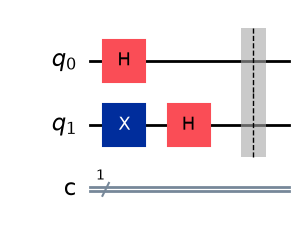

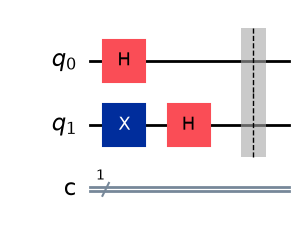

In [4]:
circuit.h(0)
circuit.x(1)
circuit.h(1)

circuit.barrier()

circuit.draw(output="mpl")

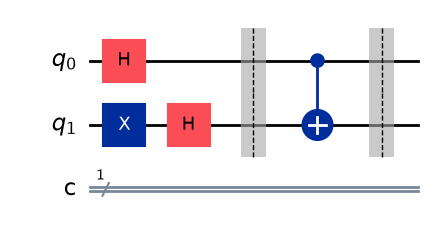

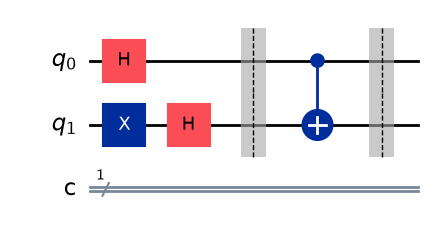

In [5]:
circuit.cx(0,1)

circuit.barrier()

circuit.draw(output="mpl")

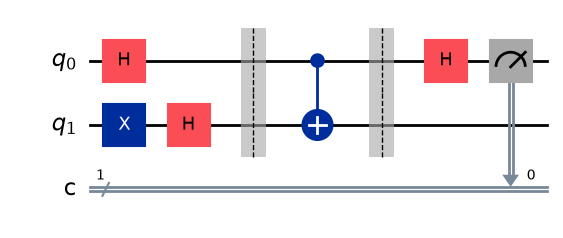

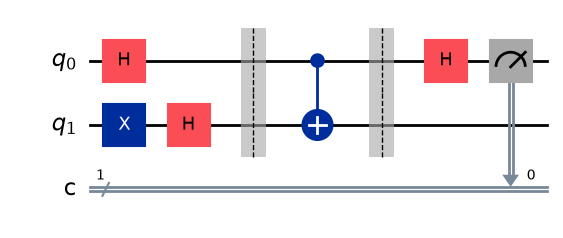

In [6]:
circuit.h(0)
circuit.measure(0,0)

circuit.draw(output="mpl")

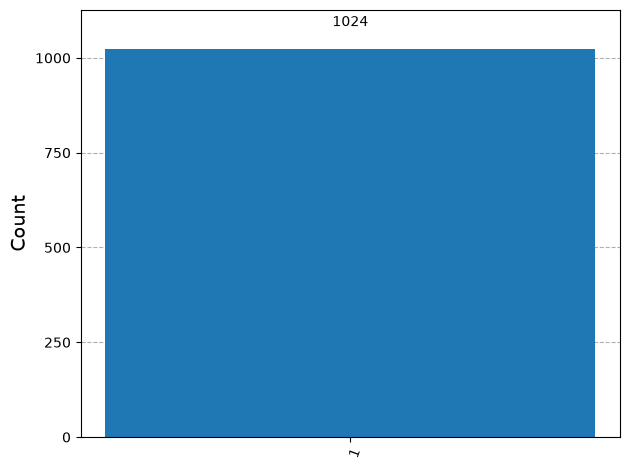

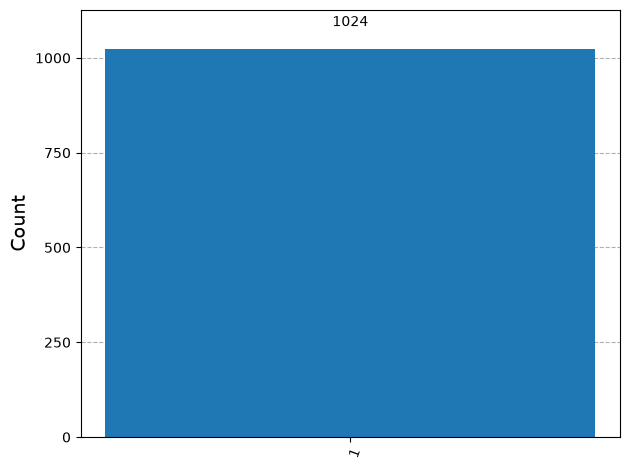

In [7]:
simulator = AerSimulator()
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots = 1024).result()
counts = result.get_counts(circuit)

plot_histogram([counts])

In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

In [9]:
print("Available backends:")
for backend in service.backends():
    print(" -", backend.name)

Available backends:
 - ibm_fez
 - ibm_kingston
 - ibm_marrakesh


In [10]:
quantum_computer = service.least_busy(operational=True, simulator=False)

In [11]:
print("Selected Backend:", quantum_computer.name)

Selected Backend: ibm_marrakesh


In [12]:
from qiskit_ibm_runtime.executor_sampler import Sampler

In [14]:
isa_circuit = transpile(circuit, backend=quantum_computer, optimization_level=1)

sampler = Sampler(mode=quantum_computer)
job = sampler.run([isa_circuit], shots=1024)
print("Job ID:", job.job_id())

Job ID: dau1i0bojkfs738rdh70


In [15]:
print("Status Before Waiting:", job.status())
result = job.result()
print("Status After Waiting :", job.status())

Status Before Waiting: QUEUED
Status After Waiting : DONE


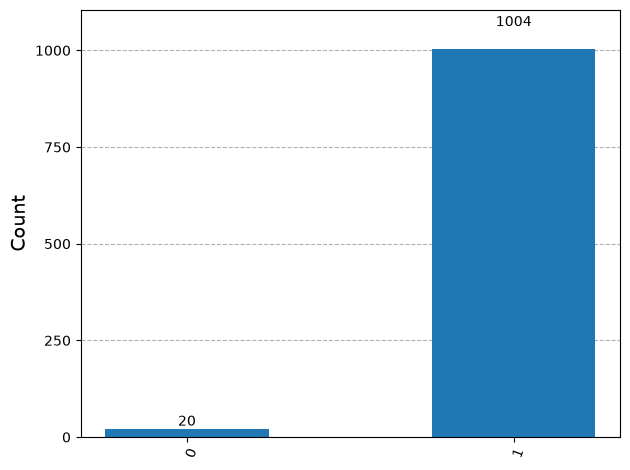

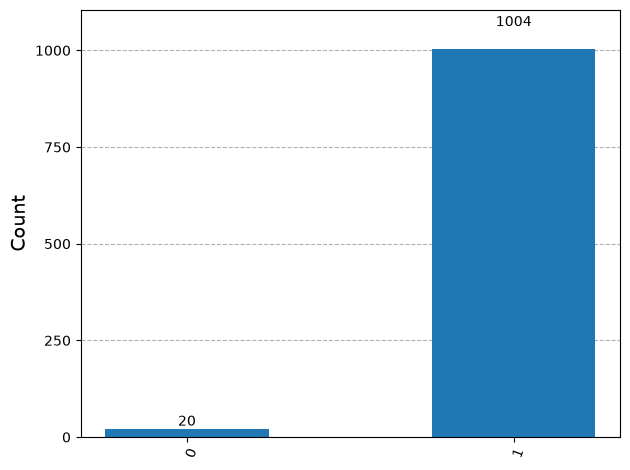

In [16]:
quantum_counts = result[0].data.c.get_counts()
plot_histogram([quantum_counts])